In [1]:
import os
import sys
import gc
import json
import time
import warnings
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torchvision import models
from pathlib import Path
from torch.optim.lr_scheduler import SequentialLR, LinearLR, CosineAnnealingLR
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

def clear_memory():
    gc.collect()
    if torch.backends.mps.is_available():
        torch.mps.empty_cache()

In [3]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
sys.path.append(str(ROOT))

from Utils.project_utils import *
import Utils.constants as c
from Utils.transforms import *
from Utils.MushroomDataset import *
from Utils.dataLoaders import *

In [4]:
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

print(f"Using device: {device}")

Using device: mps


In [5]:
SPLIT_DIR = Path.cwd().resolve() / "Data" / "splits"

In [6]:
# Load the datasets
train = pd.read_csv(SPLIT_DIR / "train.csv")
val = pd.read_csv(SPLIT_DIR / "val.csv")
test = pd.read_csv(SPLIT_DIR / "test.csv")

In [7]:
# Load the class mapping
with open(SPLIT_DIR / "class_to_idx.json", "r") as f:
    train_class_to_idx = json.load(f)

In [8]:
# Define transforms (fixing the syntax error from before)
train_tfms_mild = get_train_tfms_mild() 
train_tfms_strong = get_train_tfms_strong() 
val_tfms = get_val_tfms()

print("All files loaded successfully!")

All files loaded successfully!


In [9]:
save_dir = PROJECT_ROOT / "Graphs"
save_dir.mkdir(parents=True, exist_ok=True)

In [10]:
CLASSES = sorted(train["class"].unique().tolist())

In [11]:
loaders = make_loaders(
    train,
    val,
    test,
    train_tfms_mild,
    train_tfms_strong,
    val_tfms,
    train_class_to_idx,
    CLASSES,
    c.BATCH_SIZE,
    c.NUM_WORKERS,
    device,
)

loaders

{'train_loader_mild': <torch.utils.data.dataloader.DataLoader at 0x1690c7380>,
 'train_loader_strong': <torch.utils.data.dataloader.DataLoader at 0x1692bbc50>,
 'val_loader': <torch.utils.data.dataloader.DataLoader at 0x16977c050>,
 'test_loader': <torch.utils.data.dataloader.DataLoader at 0x1692b6190>}

In [12]:
train_loader = loaders["train_loader_strong"]
val_loader = loaders["val_loader"]
test_loader = loaders["test_loader"]

In [13]:
criterion = nn.CrossEntropyLoss()

## Training and Validation

### Load RESNET50 Model

In [14]:
model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

In [15]:
model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
model = model.to(device)

optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)

In [16]:
def run_one_epoch(model, loader, criterion, optimizer, device, is_train=False, return_preds=False):
    running_loss, running_correct, total = 0.0, 0, 0
    all_preds, all_labels = [], []
    
    start_time = time.time()
    
    if is_train:
        model.train()
    else:
        model.eval()
    
    num_batches = len(loader)
    
    for i, (img, labels) in enumerate(loader):
        img, labels = img.to(device), labels.to(device)

        if is_train:
            optimizer.zero_grad(set_to_none=True) # Better than zero_grad()
            outputs = model(img)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
        else:
            with torch.no_grad():
                outputs = model(img)
                loss = criterion(outputs, labels)

        # Update metrics
        preds = outputs.argmax(1)
        batch_size = img.size(0)
        running_loss += loss.item() * batch_size
        running_correct += (preds == labels).sum().item()
        total += batch_size

        if (i + 1) % 5 == 0 or (i + 1) == num_batches:
            elapsed = time.time() - start_time
            print(f"  Batch {i+1}/{num_batches} | Loss: {loss.item():.4f} | "
                  f"Acc: {running_correct/total:.4f} | Time: {elapsed:.1f}s", end='\r')

        if return_preds:
            all_preds.append(preds.cpu())
            all_labels.append(labels.cpu())
            
        # --- NEW: CLEAR BATCH MEMORY ---
        del img, labels, outputs, loss, preds
        if i % 10 == 0: # Clear cache every 10 batches to keep MPS stable
            if device.type == 'mps':
                torch.mps.empty_cache()

    print() 

    if return_preds:
        return (running_loss / total), (running_correct / total), total, \
               torch.cat(all_labels), torch.cat(all_preds)
    else:
        return (running_loss / total), (running_correct / total), total, None, None

In [17]:
BEST_MODEL_PATH = Path.cwd() / "best_models" / "resnet50_best.pth"

In [18]:
BEST_MODEL_PATH.parent.mkdir(parents=True, exist_ok=True)

In [19]:
def train(model, train_loader, val_loader, criterion, optimizer, num_epochs, device, patience=3):
    best_val_acc = -float("inf")
    bad_epochs = 0
    total_start_time = time.time()

    for epoch in range(num_epochs):
        epoch_start = time.time()
        print(f"\n>>> Epoch {epoch + 1}/{num_epochs} start")

        # Training phase
        train_loss, train_acc, _, _, _ = run_one_epoch(
            model, train_loader, criterion, optimizer, device, is_train=True
        )
        
        # Validation phase
        val_loss, val_acc, _, _, _ = run_one_epoch(
            model, val_loader, criterion, optimizer, device, is_train=False
        )

        epoch_time = time.time() - epoch_start
        print(f"Epoch {epoch + 1} Done | Time: {epoch_time:.1f}s")
        print(f"Stats: train_loss={train_loss:.4f}, train_acc={train_acc:.4f}, "
              f"val_loss={val_loss:.4f}, val_acc={val_acc:.4f}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            bad_epochs = 0
            torch.save(model.state_dict(), BEST_MODEL_PATH)
            print(f">>> New Best Val Acc: {val_acc:.4f}! Model Saved.")
        else:
            bad_epochs += 1
            print(f"--- No improvement. Patience: {bad_epochs}/{patience}")
            if bad_epochs >= patience:
                print("!!! Early stopping triggered.")
                break
        
        # --- NEW: SYSTEM LEVEL CLEANUP ---
        gc.collect() 
        if device.type == 'mps':
            torch.mps.empty_cache()

    total_time = time.time() - total_start_time
    print(f"\n>>> Training Complete! Total Time: {total_time/60:.1f} minutes")
    
    # Load best weights back
    model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=device))
    return model

In [20]:
train(model, train_loader, val_loader, criterion, optimizer, num_epochs=30, device=device, patience=5)


>>> Epoch 1/30 start
  Batch 151/151 | Loss: 0.3566 | Acc: 0.7696 | Time: 530.1s
  Batch 19/19 | Loss: 0.4065 | Acc: 0.8385 | Time: 26.0s
Epoch 1 Done | Time: 556.3s
Stats: train_loss=0.5446, train_acc=0.7696, val_loss=0.4071, val_acc=0.8385
>>> New Best Val Acc: 0.8385! Model Saved.

>>> Epoch 2/30 start
  Batch 151/151 | Loss: 0.4815 | Acc: 0.8429 | Time: 504.4s
  Batch 19/19 | Loss: 0.2919 | Acc: 0.8587 | Time: 23.5s
Epoch 2 Done | Time: 528.0s
Stats: train_loss=0.3837, train_acc=0.8429, val_loss=0.3401, val_acc=0.8587
>>> New Best Val Acc: 0.8587! Model Saved.

>>> Epoch 3/30 start
  Batch 151/151 | Loss: 0.3133 | Acc: 0.8689 | Time: 507.9s
  Batch 19/19 | Loss: 0.3405 | Acc: 0.8699 | Time: 23.6s
Epoch 3 Done | Time: 531.6s
Stats: train_loss=0.3259, train_acc=0.8689, val_loss=0.3229, val_acc=0.8699
>>> New Best Val Acc: 0.8699! Model Saved.

>>> Epoch 4/30 start
  Batch 151/151 | Loss: 0.2775 | Acc: 0.8838 | Time: 503.1s
  Batch 19/19 | Loss: 0.3193 | Acc: 0.8778 | Time: 23.5s
Epo

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [21]:
model.fc = nn.Linear(model.fc.in_features, len(CLASSES))
model = model.to(device)
state_dict = torch.load(BEST_MODEL_PATH, map_location=device)
model.load_state_dict(state_dict)
model.eval()

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

## Testing

In [22]:
test_loss, test_acc, test_total, test_labels, test_preds = run_one_epoch(
    model, test_loader, criterion, optimizer, device, is_train=False, return_preds=True
)

  Batch 19/19 | Loss: 0.4379 | Acc: 0.8827 | Time: 24.8s


In [23]:
print("Test accuracy:", test_acc)

Test accuracy: 0.8827070790948723


In [24]:
cm = confusion_matrix(test_labels, test_preds)
print("Confusion matrix:\n", cm)
print("\nClassification report:\n",
    classification_report(test_labels, test_preds, target_names=CLASSES, digits=4))

Confusion matrix:
 [[1396  140   69]
 [ 106 1396  104]
 [  63   83 1460]]

Classification report:
                       precision    recall  f1-score   support

conditionally_edible     0.8920    0.8698    0.8808      1605
              edible     0.8623    0.8692    0.8657      1606
               toxic     0.8941    0.9091    0.9015      1606

            accuracy                         0.8827      4817
           macro avg     0.8828    0.8827    0.8827      4817
        weighted avg     0.8828    0.8827    0.8827      4817



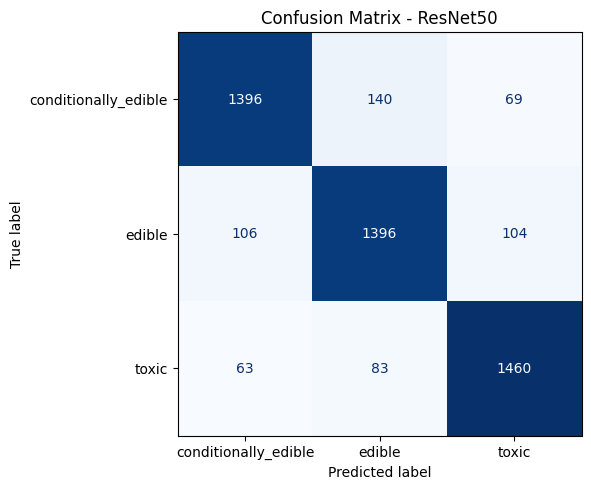

In [25]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
fig, ax = plt.subplots(figsize=(6,6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)

plt.title("Confusion Matrix - ResNet50")
plt.tight_layout()

# 3. SAVE FIRST, THEN SHOW
plt.savefig(save_dir / "resnet50_confusion_matrix.png", dpi=300)
plt.show()